## ddHodge on surface

## Setup

In [ ]:
using ddHodge
using GLMakie, GraphMakie, LinearAlgebra
using KrylovKit: eigsolve
using StatsBase: sample, mean, quantile, msd, rmsd

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa, SurfaceFun.sphere

### Set graphic theme

In [2]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Surface

In [3]:
# Drawing shpere or torus
function uvsurface!(ax, shape;resol=200, scale=1.0, colorfun = (u,v) -> :steelblue, opts...)
    rlon = LinRange(-pi,pi,resol)
    rlat = if shape.type == :sphere 
        LinRange(-pi/2,pi/2-1e-6,resol)
    else
        LinRange(-pi,pi-1e-6,Int(resol/2))
    end
    # get i-th values
    slice(arr::Matrix,i::Int) = get.(arr,i,missing)
    # rescale radius for some purpose
    newshape = SetShape(shape.type;r=scale*shape.par.r)
    S = newshape.f.(rlon,rlat')
    plt = surface!(
        ax, [slice(S,i) for i in 1:3]...;
        color = colorfun.(rlon,rlat'),
        shading=NoShading, transparency=false
    )
    [plt[k] = v for (k,v) in opts] # set options
    plt
end

uvsurface! (generic function with 1 method)

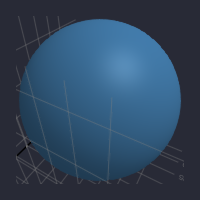

In [4]:
shape = SetShape(:sphere; r=1.0)
#shape = SetShape(:torus; r=0.5)

# Camera parameters
cpars = let
    eyedist = shape.type == :sphere ? shape.par.r + 1.7 : 4.0
    (
        eyeposition = Vec3f(eyedist*sphere(-pi/3,40pi/180,r=1.0)),
        lookat = shape.type == :sphere ? Vec3f(0) : Vec3f(0,0,-0.2),
        up = Vec3f(0,0,1)
    )
end

# Check settings
fig = Figure(size=(200,200))
ax = LScene(fig[1,1])
uvsurface!(ax,shape,shading=MultiLightShading)
cam3d!(ax.scene, center=false)
update_cam!(ax.scene, cpars...)
fig

In [5]:
Makie.inline!(false);display(fig);Makie.inline!(true)

true

## Dynamical system

In [6]:
# Predefined 1/|√g|
drgi = let r = shape.par.r
    if shape.type == :sphere
        (x,y) -> 1/(r^2*cos(y))
    else
        (x,y) -> 1/(r*(1.0+r*cos(y)))
    end
end

J, G, Dc, divM, curlM = diffOpsM(shape.f;drgi=drgi)
μc = [-pi/2,0.0] # center of the potential peak

if shape.type == :sphere
    # For sphere: log-vMF
    U(x,y;μ=μc,κ=1.0) = κ*sphere(μ...)'*sphere(x,y)
else
    # log cosine-BVMC energy on torus
    lbvmc(x,y;mx=0,my=0,k1=1,k2=1,k3=0) = k1*cos(x-mx)+k2*cos(y-my)+k3*cos(x-mx-y+my)
    # Scalar field of energy landscape U
    U(x,y) = 0.5*lbvmc(x,y,mx=μc[1],my=μc[2])
end

fg(x,y) = -∇(U)(x,y) # gradient part
fc(x,y) = [cos(y)^2,0] # curl part for sphere: J*g^-1*F = du
fp(x,y) = fg(x,y) + fc(x,y) # vector field on parameter space

# Velocity on parameter space for simulation
vfp(x) = G(x...)\fp(x...) # inverse-scaled vector field
# Velocity on tangent plane for observation
vft(x) = J(x...)*vfp(x) # (J √g⁻¹)'(J √g⁻¹) = I

# Vector calculus on M
divRM = divM(fp)
curlRM = curlM(fp)

#23 (generic function with 1 method)

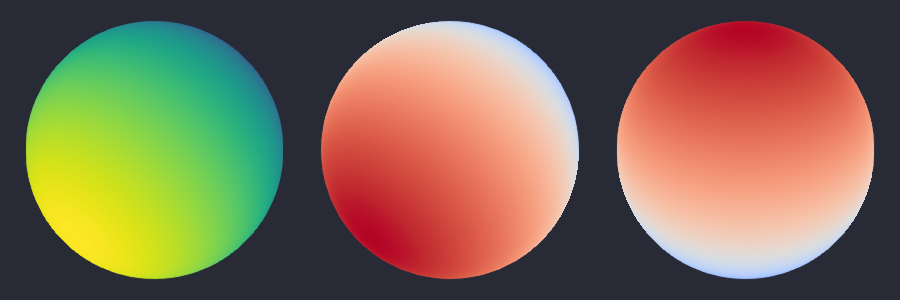

In [7]:
fig = let vmax=2
    fig = Figure(size=(900,300))
    axs = [LScene(fig[1,i],show_axis=false) for i in 1:3]
    uvsurface!(axs[1], shape, colorfun=U, colormap=:viridis)
    uvsurface!(axs[2], shape, colorfun=divRM, colormap=:coolwarm, colorrange=(-vmax,vmax))
    uvsurface!(axs[3], shape, colorfun=curlRM, colormap=:coolwarm, colorrange=(-vmax,vmax))
    for i in eachindex(axs)
        cam3d!(axs[i].scene, center=false)
        update_cam!(axs[i].scene, cpars...)
    end
    fig
end

## Uniform sampling on surface

In [8]:
# Uniform sampling on surface by the *easy* inverse sampling
function fakesample(n;type=:sphere)
    # Define probability P(x) using integration of riemannian metric
    if type == :sphere
        #pφ(x) = (x-sin(x)*cos(x))/pi
        pφ = x -> (1 + sin(x))/2
    else
        r=0.5
        R=1.0
        pφ = x -> ((x+pi)*(r^2+2R^2)+r*sin(x)*(r*cos(x)+4R))/2(pi*(r^2+2R^2))
    end
    # easy table imprementation of inverse function
    intrange = collect(LinRange((type == :sphere ? (-pi/2,pi/2) : (-pi,pi))...,1000))
    invtable = pφ.(intrange)
    [intrange[argmin(abs.(x.-invtable))] for x in rand(n)]
end

fakesample (generic function with 1 method)

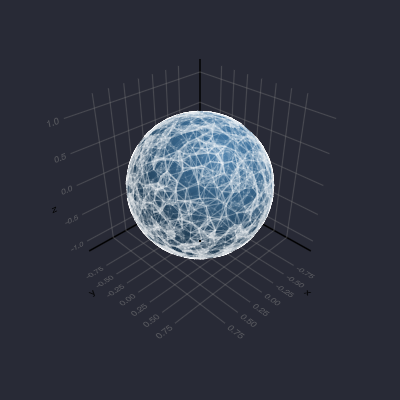

In [9]:
N = 2000
X2 = [pi*(2rand(N).-1) fakesample(N;shape.type)]'
V2 = hcat(vfp.(eachcol(X2))...)
X = hcat(spa(shape.f).(eachcol(X2))...)
pts2 = Point2f.(eachcol(X2))
pts3 = Point3f.(spa(shape.f).(pts2))
V = hcat(vft.(eachcol(X2))...)
g, kdtree, = kNNGraph(X,10)
fig = Figure(size=(400,400))
ax = LScene(fig[1,1])
uvsurface!(ax, shape, transparency=true, shading=MultiLightShading)
graphplot!(ax,g,layout=pts3,node_size=0,edge_width=0.5,edge_attr=(transparency=true,))
fig

## Run ddHodge

In [10]:
ztop = argmax(X[3,:]) # the reference of face orientation
ddh = ddHodgeWorkflow(g,X,V,rdim=2,λ=0.1,ϵ=0.1,ssa=true,krytol=1e-32,useCUDA=false,ssart=ztop)
ttu = hcat([ddh.frames[i][:,1] for i in 1:N]...) # parallel axis u
ttv = hcat([ddh.frames[i][:,2] for i in 1:N]...) # parallel axis v
# The sign of the rotation depends on the face orientation
fo = sign(det(ddh.planes[ztop][1:2,:])) # sign of z in (x,y,z) = u × v
@info "face orientation is $fo"
extrema(vec(sum(ttu.*ttv,dims=1))) # orthogonality of the axes

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.196 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.904 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 3.289 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 2.221 sec.
[ Info: face orientation is 1.0


(-1.1768569452286215e-10, 1.1615861050806586e-11)

## Check results

[msd(xs, ys) for (xs, ys) = vpairs] = [0.001249871620510066, 0.00045205061338832224, 0.001063193520595699]


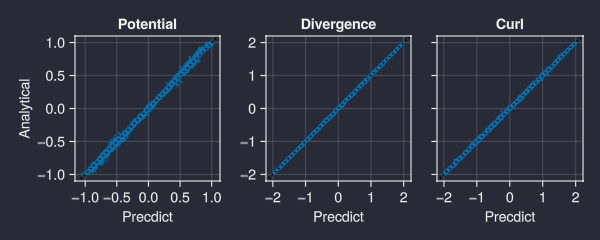

In [11]:
fig = let
    uana, divana, rotana = [f.(pts2) for f in spa.([U,divM(fp),curlM(fp)])]
    vmax = quantile([divana;rotana],0.99)
    ub = mean(ddh.u-uana) # bias can be ignored 
    vpairs = [(ddh.u.-ub, uana), (ddh.div, divana), (fo*ddh.rot, rotana)]
    @show [msd(xs,ys) for (xs,ys) in vpairs]
    fig = Figure(size=(600,240))
    titles = ["Potential","Divergence","Curl"]
    axs = [Axis(fig[1,i],aspect=1,xlabel="Precdict",title=titles[i]) for i in 1:3]
    [scatter!(axs[i], vpairs[i]..., markersize=2, rasterize=true) for i in eachindex(vpairs)]
    [axs[i].yticklabelsvisible=false for i in 3]
    axs[1].ylabel = "Analytical"
    linkaxes!(axs[2:3]...)
    [ablines!(axs[i], [0], [1], color=:black, linestyle=:dot) for i in 1:3]
    fig
end

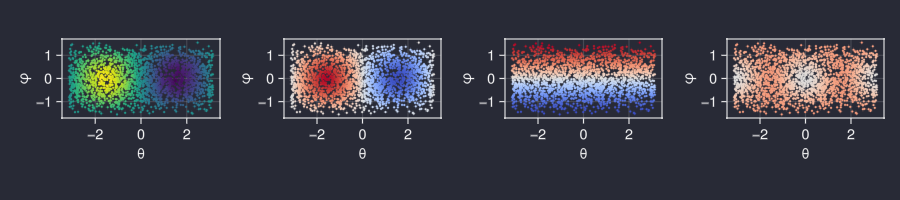

In [12]:
let ms = 3, vmax=2
    fig = Figure(size=(900,200))
    axs = [Axis(fig[1,i],aspect=2,xlabel="θ",ylabel="φ") for i in 1:4]
    scatter!(axs[1],pts2,color=ddh.u,markersize=ms,colormap=:viridis)
    for (i,vals) in enumerate([ddh.div, fo*ddh.rot, det.(ddh.J)])
        scatter!(axs[i+1],pts2,color=vals,markersize=ms,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=true)
    end
    fig
end

  9.930965 seconds (7.58 M allocations: 5.139 GiB, 12.52% gc time, 42.38% compilation time)


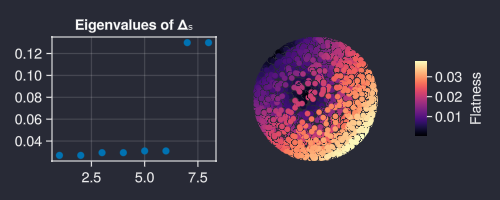

In [13]:
fig = let i=1, krytol=1e-32 # > 1e-16 may fail: 
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=krytol)
    vlens = norm.(eachcol(reshape(vecs[i],2,:)))
    fig = Figure(size=(500,200))
    ax1 = Axis(fig[1,1],title="Eigenvalues of Δₛ")
    scatter!(ax1,vals,markersize=10)
    ax2 = LScene(fig[1,2],show_axis=false)
    #uvsurface!(ax2,shape,colorfun=(u,v) -> :white,transparency=true,scale=0.99)
    p = scatter!(ax2,pts3,color=vlens,colormap=:magma,markersize=8)
    #vps = ddh.frames .* eachcol(reshape(vecs[i],2,:)) .* vlens.^-1
    #p = quiver!(ax2,pts3,Vec3f.(0.1vps),linewidth=0.005,arrowsize=0,color=vlens,transparency=true,colormap=:cool)
    #quiver!(ax2,pts3,-Vec3f.(0.1vps),linewidth=0.005,arrowsize=0,color=vlens,transparency=true,colormap=:cool)
    cam3d!(ax2.scene, center=false)
    update_cam!(ax2.scene, cpars...)
    Colorbar(fig[1,3],p,height=Relative(0.6),label="Flatness")
    fig
end

  4.267326 seconds (386.13 k allocations: 3.775 GiB, 15.76% gc time)


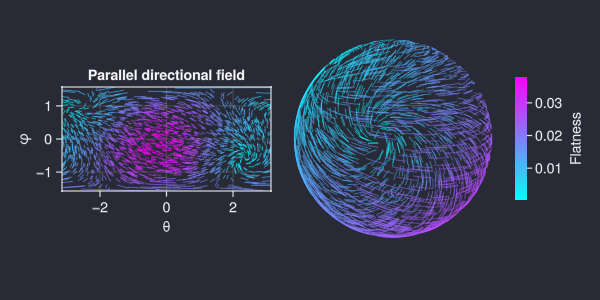

In [14]:
function makepal(cmap,x;resol=256)
    x = x .- minimum(x)
    idx = Int.(ceil.(x/maximum(x)*(resol-1))) # 0...255
    cgrad(cmap,resol)[idx.+1] # 1...256
end

fig = let i=1, j=i+1, b=[0,1], α=0.05, cmap=:cool, krytol=1e-18 # > 1e-16 may fail
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=krytol)
    ulens = norm.(eachcol(reshape(vecs[i],2,:))) # norm(u) relates to the curvature
    # Prallel vector field on tangent planes
    ttu, ttv = [ddh.spans .* normalize.(eachcol(reshape(vecs[k],2,:))) for k in [i,j]]
    # Tangent -> param. space: vp = G^-1*J'*vt since Vt = J*vp
    T2P = [G(p...)\J(p...)' for p in pts2]
    ups, vps = [T2P .* ttx for ttx in [ttu,ttv]]
    zps = [Vec2f([u v]*b) for (u,v) in zip(ups,vps)]
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=2,xlabel="θ",ylabel="φ",title="Parallel directional field")
    q = quiver!(ax1,pts2-α*zps,2α*zps,arrowsize=0,linewidth=0.6,color=ulens,colormap=cmap)
    xlims!(ax1,-pi,pi)
    yrange = shape.type == :sphere ? (-pi/2,pi/2) : (-pi,pi)
    ylims!(ax1,yrange...)
    Colorbar(fig[1,3],q,height=Relative(0.6),label="Flatness")
    ax2 = LScene(fig[1,2],show_axis=false)
    pal = makepal(cmap,ulens)
    for (i,p,v) in zip(eachindex(pts2), pts2, zps)
        traj = Point3f.(spa(shape.f).(LinRange(p-α*v,p+2α*v,40)))
        lines!(ax2,traj,color=pal[i],linewidth=0.5,transparency=true)
    end
    cam3d!(ax2.scene, center=false)
    update_cam!(ax2.scene, cpars...)
    fig
end

In [15]:
fig = let i=5, j=6, α=0.08, cmap=:cool, by=1, tmax=100
    psrc = Observable(fill(Point2f(0),N))
    pdst = Observable(fill(Point2f(0),N))
    wlens = Observable(fill(0.0,N))
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=1e-18)
    #ulens = norm.(eachcol(reshape(vecs[i],2,:))) # norm(u) relates to the curvature
    # Prallel vector field on tangent planes
    us, vs = [eachcol(reshape(vecs[k],2,:)) for k in [i,j]]
    #ulens, vlens = [norm.(xs) for xs in [us,vs]]
    ttu, ttv = [ddh.spans .* normalize.(xs) for xs in [us,vs]]
    # Tangent -> param. space: vp = G^-1*J'*vt since Vt = J*vp
    T2P = [G(p...)\J(p...)' for p in pts2]
    ups, vps = [T2P .* ttx for ttx in [ttu,ttv]] # T2P*P*b
    fig = Figure(size=(500,300))
    ax1 = Axis(fig[1,1],aspect=2,xlabel="θ",ylabel="φ",title="Parallel directional field")
    q = quiver!(ax1,psrc,pdst,arrowsize=0,linewidth=0.6,color=wlens,colormap=cmap)
    xlims!(ax1,-pi,pi)
    yrange = shape.type == :sphere ? (-pi/2,pi/2) : (-pi,pi)
    ylims!(ax1,yrange...)
    #Colorbar(fig[1,2],q,height=Relative(0.6),label="Flatness")
    vio = Record(fig, 1:by:tmax; framerate=30, profile ="high") do i
        θ = pi*i/tmax
        b = [cos(θ),sin(θ)]
        wlens[] = [norm([u v]*b) for (u,v) in zip(us,vs)]
        wps = [Vec2f([u v]*b) for (u,v) in zip(ups,vps)]
        psrc[] = pts2-α*wps
        pdst[] = 2α*wps
    end
end

  4.873033 seconds (386.15 k allocations: 3.775 GiB, 20.57% gc time)


VideoStream(Base.PipeEndpoint(RawFD(79) open, 0 bytes waiting), Process(setenv(`/home/kazumitsu.maehara/.julia/artifacts/5b83972689fb7dea5e89326f1c0ba60d68e962fb/bin/ffmpeg -y -loglevel quiet -threads 48 -framerate 30 -pixel_format rgb24 -f rawvideo -s:v 500x300 -r 30 -i pipe:0 -vf vflip -profile:v high -crf 20 -preset slow -c:v libx264 -pix_fmt yuv420p -an '/tmp/jl_NruzLf/##video#230.mp4'`,["XKB_CONFIG_ROOT=/home/kazumitsu.maehara/.julia/artifacts/f8b49c7c45b400e3f5c4002d19645d4b88712c0c/share/X11/xkb", "PATH=/home/kazumitsu.maehara/.julia/artifacts/b8a470e4553346122607f94ec60d83c77f061cd6/bin:/home/kazumitsu.maehara/.julia/artifacts/7f882b869c126a717e15be05453b83bd9135eab0/bin:/home/kazumitsu.maehara/.julia/artifacts/96bc7b9ddb319d1a051535c85184aa2bf42dbd8b/bin:/home/kazumitsu.maehara/.julia/artifacts/bd752d7807f5f10e2dce3d2b2b683589fa03d31a/bin:/home/kazumitsu.maehara/.julia/artifacts/c8a20a2030f10b70947d8d2a6bff7f8b5f343fe9/bin:/home/kazumitsu.maehara/.julia/artifacts/0b5269206a6849e48487ed04136c30b1f12443e7/bin:/home/kazumitsu.maehara/.julia/artifacts/587de110e5f58fd435dc35b294df31bb7a75f692/bin:/home/kazumitsu.maehara/.julia/artifacts/fc239b3ff5739aeab252bd154fa4dd045fefe629/bin:/home/kazumitsu.maehara/.julia/artifacts/8be4b2d49ed77db4f9607e5f8a7b09cc105be2ee/bin:/home/kazumitsu.maehara/.julia/artifacts/5b83972689fb7dea5e89326f1c0ba60d68e962fb/bin:/usr/local/packages/mambaforge/bin", "JULIA_PROJECT=@.", "JPY_SESSION_NAME=/home/kazumitsu.maehara/pynb/ddHodge_figures/notebook/surfsim_fig.ipynb", "DISPLAY=:1", "COLUMNS=80", "JUPYTERHUB_BASE_URL=/", "SHELL=/bin/bash", "JUPYTERHUB_OAUTH_ACCESS_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JPY_API_TOKEN=75189a2751e8474d83eec23039d06929"  …  "LINES=30", "JUPYTERHUB_DEFAULT_URL=/lab", "LIBDECOR_PLUGIN_DIR=/home/kazumitsu.maehara/.julia/artifacts/38e215c51e5c0f77bc7a8813ba4586632a8fc750/lib/libdecor/plugins-1", "HOME=/home/kazumitsu.maehara", "JUPYTERHUB_USER=kazumitsu.maehara", "JUPYTERHUB_CLIENT_ID=jupyterhub-user-kazumitsu.maehara", "JUPYTERHUB_COOKIE_HOST_PREFIX_ENABLED=0", "JUPYTERHUB_OAUTH_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JUPYTERHUB_SERVICE_PREFIX=/user/kazumitsu.maehara/", "OPENBLAS_MAIN_FREE=1"]), ProcessRunning), GLMakie.Screen(...), Makie.TickController(Observable(Makie.Tick(Makie.OneTimeRenderTick, 100, 3.3333333333333335, 0.03333333333333333)), 101, 0.03333333333333333, true, ObserverFunction defined at /home/kazumitsu.maehara/.julia/packages/Makie/ux0Te/src/ffmpeg-util.jl:191 operating on Observable(Tick(OneTimeRenderTick, 100, 3.33333, 0.0333333))), ColorTypes.RGB{FixedPointNumbers.N0f8}[RGB(0.69, 0.451, 0.004) RGB(0.0, 0.0, 0.0) … RGB(0.263, 0.914, 0.192) RGB(0.184, 0.008, 0.506); RGB(0.051, 0.796, 0.498) RGB(0.0, 0.741, 0.0) … RGB(0.831, 0.945, 0.722) RGB(0.247, 0.384, 0.6); … ; RGB(0.0, 0.0, 0.737) RGB(0.0, 0.0, 0.0) … RGB(0.361, 0.247, 0.761) RGB(0.0, 0.0, 0.0); RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0) … RGB(0.788, 0.102, 0.616) RGB(0.0, 0.0, 0.0)], "/tmp/jl_NruzLf/##video#230.mp4", Makie.VideoStreamOptions("mp4", 30, 20, "high", "yuv420p", 0, "quiet", "pipe:0", true))